## 1. Setup Environment

Install libraries for YOLO inference/training, BMD-45 sampling, automatic ROI generation, visualization, and JSON output.

In [ ]:
!pip install ultralytics opencv-python pandas numpy matplotlib PyYAML tqdm huggingface_hub shapely Pillow -q

### Check GPU Availability

In [ ]:
import torch

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current CUDA device: {torch.cuda.current_device()}")
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: CUDA is not available. Training and inference will run on CPU.")

CUDA available: True
CUDA device count: 1
Current CUDA device: 0
CUDA device name: Tesla T4


## 2. Create Project Folder Structure

In [ ]:
import os

for directory in [
    'project/data/raw',
    'project/data/annotations',
    'project/data/processed',
    'project/data/splits',
    'project/config',
    'project/outputs',
    'project/src',
    'project/notebooks',
]:
    os.makedirs(directory, exist_ok=True)
    print(f"Ready: {directory}")

with open('project/src/__init__.py', 'w') as f:
    f.write('')

Ready: project/data/raw
Ready: project/data/annotations
Ready: project/data/processed
Ready: project/data/splits
Ready: project/config
Ready: project/outputs
Ready: project/src
Ready: project/notebooks


## 3. Create Default Configuration

This project now detects vehicles from one randomly selected BMD-45 image and writes REST API-friendly JSON.

In [ ]:
import os
import yaml
import torch

config = {
    'system': {'name': 'Traffic Intersection Image Detector', 'version': '2.0.0'},
    'paths': {
        'base': 'project',
        'data_raw': 'project/data/raw',
        'data_annotations': 'project/data/annotations',
        'data_processed': 'project/data/processed',
        'data_splits': 'project/data/splits',
        'config': 'project/config',
        'outputs': 'project/outputs',
        'src': 'project/src',
    },
    'drive': {
        'model_path': '/content/drive/MyDrive/traffic_light_ai_project/outputs/best.pt',
        'auto_mount': True,
    },
    'test': {
        'mode': 'image',
        'sample_limit_mb': 500,
        'session_history': 'project/outputs/used_images.json',
        'selected_image_path': None,
    },
    'dataset': {
        'name': 'BMD_45_vehicle_dataset',
        'names': ['motor', 'auto', 'car', 'heavy'],
        'remapped_classes': {
            'motor': 0, 'motorcycle': 0, 'motorbike': 0, 'bike': 0,
            'two_wheeler': 0, '2_wheeler': 0, '2wheeler': 0, 'bicycle': 0,
            'auto': 1, 'auto_rickshaw': 1, 'rickshaw': 1,
            'three_wheeler': 1, '3_wheeler': 1, '3wheeler': 1,
            'car': 2, 'vehicle': 2, 'hatchback': 2, 'sedan': 2, 'suv': 2, 'muv': 2,
            'van': 2, 'jeep': 2,
            'bus': 3, 'truck': 3, 'heavy': 3, 'heavy_vehicle': 3,
            'lcv': 3, 'mini_bus': 3, 'tempo_traveller': 3, 'lorry': 3, 'trailer': 3,
        },
        'img_size': 640,
        'split_seed': 42,
        'bmd45': {
            'repo_id': 'iisc-aim/BMD-45',
            'sample_limit_gb': 10,
            'random_seed': 42,
            'max_workers': 16,
            'download_batch_size': 64,
            'splits': {'train': 'BMD-45-Train', 'val': 'BMD-45-Val'},
        },
    },
    'training': {
        'model': 'yolov8n.pt',
        'imgsz': 640,
        'epochs': 100,
        'batch': 16,
        'patience': 20,
        'project': 'runs/train',
        'name': 'yolov8n_custom',
    },
    'inference': {
        'model_path': 'project/outputs/best.pt',
        'conf_threshold': 0.25,
        'iou_threshold': 0.45,
        'device': 0 if torch.cuda.is_available() else 'cpu',
    },
    'roi_counting': {'roi_polygons': {'North': [], 'East': [], 'South': [], 'West': []}},
    'output_files': {
        'label_quality_report': 'label_quality_report.md',
        'detection_result_json': 'detection_result.json',
        'annotated_image': 'annotated_intersection.jpg',
    },
    'SKIP_TRAINING': False,
}

for key in ['base', 'data_raw', 'data_annotations', 'data_processed', 'data_splits', 'config', 'outputs', 'src']:
    os.makedirs(config['paths'][key], exist_ok=True)

config_path = 'project/config/default.yaml'
with open(config_path, 'w') as f:
    yaml.safe_dump(config, f, sort_keys=False)

print(f"Default configuration saved to {config_path}")

Default configuration saved to project/config/default.yaml


## 3.5. Drive Model Gate

If `/content/drive/MyDrive/traffic_light_ai_project/outputs/best.pt` exists, use it and skip training. BMD-45 is still sampled for random test images.

In [ ]:
import os
import yaml

config_path = 'project/config/default.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

if config['drive'].get('auto_mount', True):
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        print('Google Drive mounted.')
    except Exception as e:
        print(f'Google Drive mount skipped or unavailable: {e}')

drive_model_path = config['drive']['model_path']
if os.path.exists(drive_model_path):
    config['inference']['model_path'] = drive_model_path
    config['SKIP_TRAINING'] = True
    print(f'Model found: {drive_model_path}')
    print('Training and data.yaml generation will be skipped.')
else:
    config['SKIP_TRAINING'] = False
    print(f'No Drive model found at: {drive_model_path}')
    print('Notebook will prepare data and train a model after sampling BMD-45.')

with open(config_path, 'w') as f:
    yaml.safe_dump(config, f, sort_keys=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
Model found: /content/drive/MyDrive/traffic_light_ai_project/outputs/best.pt
Training and data.yaml generation will be skipped.


## 4. Download BMD-45 Image Sample

Downloads a random BMD-45 sample with one readable progress bar. If a Drive model exists, the target is 500 MB by default. Otherwise the target is 10 GB for training.

In [ ]:
import os
import json
import random
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import yaml
from tqdm.auto import tqdm
from huggingface_hub import HfApi, hf_hub_download

config_path = 'project/config/default.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

bmd_cfg = config['dataset']['bmd45']
repo_id = bmd_cfg['repo_id']
skip_training = bool(config.get('SKIP_TRAINING', False))
target_bytes = int(config['test']['sample_limit_mb'] * 1024 ** 2) if skip_training else int(float(bmd_cfg['sample_limit_gb']) * 1024 ** 3)
seed = int(bmd_cfg.get('random_seed', 42))
max_workers = int(bmd_cfg.get('max_workers', 16))
download_batch_size = int(bmd_cfg.get('download_batch_size', max_workers * 4))

raw_root = Path(config['paths']['data_raw'])
source_dir = raw_root / 'bmd45' / 'source'
annotations_dir = raw_root / 'bmd45' / 'annotations'
source_dir.mkdir(parents=True, exist_ok=True)
annotations_dir.mkdir(parents=True, exist_ok=True)
image_suffixes = {'.jpg', '.jpeg', '.png', '.bmp'}


def format_bytes(num_bytes):
    value = float(num_bytes)
    for unit in ['B', 'KB', 'MB', 'GB', 'TB']:
        if value < 1024 or unit == 'TB':
            return f'{value:.2f} {unit}'
        value /= 1024


def local_image_size():
    return sum(p.stat().st_size for p in source_dir.rglob('*') if p.is_file() and p.suffix.lower() in image_suffixes)


def normalize_remote_image_path(split_dir, file_name, repo_files):
    file_name = str(file_name).replace('\\', '/').lstrip('/')
    candidates = []
    if file_name.startswith(split_dir + '/'):
        candidates.append(file_name)
    candidates.extend([f'{split_dir}/{file_name}', file_name])
    return next((candidate for candidate in candidates if candidate in repo_files), candidates[0])


def download_annotations():
    downloaded = {}
    for split, split_dir in bmd_cfg['splits'].items():
        remote_path = f'{split_dir}/_annotations.coco.json'
        local_path = hf_hub_download(
            repo_id=repo_id,
            repo_type='dataset',
            filename=remote_path,
            local_dir=str(source_dir),
            local_dir_use_symlinks=False,
        )
        downloaded[split] = Path(local_path)
    return downloaded


def build_items(annotation_paths):
    print('Listing BMD-45 files from Hugging Face...')
    repo_files = set(HfApi().list_repo_files(repo_id=repo_id, repo_type='dataset'))
    items = []
    coco_by_split = {}
    for split, ann_path in annotation_paths.items():
        with open(ann_path, 'r', encoding='utf-8') as f:
            coco = json.load(f)
        coco_by_split[split] = coco
        split_dir = bmd_cfg['splits'][split]
        for image in coco.get('images', []):
            remote_path = normalize_remote_image_path(split_dir, image.get('file_name', ''), repo_files)
            if Path(remote_path).suffix.lower() not in image_suffixes:
                continue
            items.append({'split': split, 'image_id': image['id'], 'file_name': image.get('file_name', ''), 'remote_path': remote_path})
    rng = random.Random(seed)
    rng.shuffle(items)
    return items, coco_by_split


def download_one(item):
    local_path = hf_hub_download(
        repo_id=repo_id,
        repo_type='dataset',
        filename=item['remote_path'],
        local_dir=str(source_dir),
        local_dir_use_symlinks=False,
    )
    path = Path(local_path)
    result = dict(item)
    result['local_path'] = str(path)
    result['size_bytes'] = path.stat().st_size if path.exists() else 0
    return result


def write_sampled_annotations(selected_items, coco_by_split):
    ids_by_split = {'train': set(), 'val': set()}
    remote_by_split = {'train': {}, 'val': {}}
    for item in selected_items:
        ids_by_split[item['split']].add(item['image_id'])
        remote_by_split[item['split']][item['image_id']] = item['remote_path']

    sampled_paths = {}
    for split, coco in coco_by_split.items():
        keep_ids = ids_by_split[split]
        sampled_images = []
        for image in coco.get('images', []):
            if image['id'] in keep_ids:
                copy = dict(image)
                copy['file_name'] = remote_by_split[split][image['id']]
                sampled_images.append(copy)
        sampled_annotations = [ann for ann in coco.get('annotations', []) if ann.get('image_id') in keep_ids]
        out_path = annotations_dir / f'{split}.sampled.coco.json'
        with open(out_path, 'w', encoding='utf-8') as f:
            json.dump({'images': sampled_images, 'annotations': sampled_annotations, 'categories': coco.get('categories', [])}, f)
        sampled_paths[split] = str(out_path)
        print(f'Sampled {split}: {len(sampled_images)} images, {len(sampled_annotations)} annotations')
    return sampled_paths


print(f"Preparing BMD-45 sample. Target: {format_bytes(target_bytes)}. Mode: {'inference-only' if skip_training else 'training'}")
annotation_paths = download_annotations()
items, coco_by_split = build_items(annotation_paths)
print(f'Candidate images: {len(items)}')

failures = []
current_size = local_image_size()
progress_total = max(target_bytes, current_size) if current_size > target_bytes else target_bytes
pbar = tqdm(total=progress_total, initial=min(current_size, progress_total), unit='B', unit_scale=True, desc='BMD-45 image sample')
if current_size < target_bytes:
    for start in range(0, len(items), download_batch_size):
        if local_image_size() >= target_bytes:
            break
        batch = items[start:start + download_batch_size]
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = [executor.submit(download_one, item) for item in batch]
            for future in as_completed(futures):
                try:
                    item = future.result()
                    pbar.update(item.get('size_bytes', 0))
                except Exception as e:
                    failures.append(str(e))
        pbar.set_postfix(downloaded=format_bytes(min(local_image_size(), target_bytes)), target=format_bytes(target_bytes))
pbar.close()

selected_items = []
selected_bytes = 0
for item in items:
    local_path = source_dir / item['remote_path']
    if not local_path.exists():
        continue
    item = dict(item)
    item['local_path'] = str(local_path)
    item['size_bytes'] = local_path.stat().st_size
    selected_items.append(item)
    selected_bytes += item['size_bytes']
    if selected_bytes >= target_bytes:
        break

sampled_paths = write_sampled_annotations(selected_items, coco_by_split)
config['dataset']['source'] = 'bmd45_huggingface_sample'
config['dataset']['bmd45']['sampled_annotations'] = sampled_paths
config['dataset']['bmd45']['source_dir'] = str(source_dir)
config['dataset']['bmd45']['active_target_bytes'] = target_bytes
manifest_path = annotations_dir / 'sample_manifest.json'
with open(manifest_path, 'w') as f:
    json.dump({
        'dataset': 'bmd45',
        'repo_id': repo_id,
        'skip_training': skip_training,
        'target_bytes': target_bytes,
        'target_human': format_bytes(target_bytes),
        'selected_bytes': selected_bytes,
        'selected_human': format_bytes(selected_bytes),
        'download_failures': len(failures),
        'sampled_annotations': sampled_paths,
    }, f, indent=2)

with open(config_path, 'w') as f:
    yaml.safe_dump(config, f, sort_keys=False)

print(f'Images on disk: {format_bytes(local_image_size())}')
print(f'Selected sample: {format_bytes(selected_bytes)} across {len(selected_items)} images')
print(f'Download failures: {len(failures)}')
print(f'Sample manifest saved to: {manifest_path}')

Preparing BMD-45 sample. Target: 500.00 MB. Mode: inference-only


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Listing BMD-45 files from Hugging Face...
Candidate images: 45986


BMD-45 image sample: 100%|##########| 10.9G/10.9G [00:00<?, ?B/s]

Sampled train: 123 images, 1346 annotations
Sampled val: 37 images, 382 annotations
Images on disk: 10.13 GB
Selected sample: 502.61 MB across 160 images
Download failures: 0
Sample manifest saved to: project/data/raw/bmd45/annotations/sample_manifest.json


## 5. Convert BMD-45 COCO to YOLO and Save Manifest

Creates `project/data/processed/processed_manifest.json`, which is used by random image selection and keeps the notebook restart-safe.

In [ ]:
import os
import json
import yaml
import shutil
from pathlib import Path
from collections import defaultdict
from PIL import Image

config_path = 'project/config/default.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

raw_path = Path(config['paths']['data_raw'])
processed_path = Path(config['paths']['data_processed'])
images_root = processed_path / 'images'
labels_root = processed_path / 'labels'
images_root.mkdir(parents=True, exist_ok=True)
labels_root.mkdir(parents=True, exist_ok=True)
remapped_classes = config['dataset']['remapped_classes']
issues = []
class_mapping_summaries = []
processed_image_paths = []
processed_label_paths = []


def normalize_class_name(name):
    return str(name).strip().lower().replace(' ', '_').replace('-', '_')


def map_category_to_target(category_name):
    name = normalize_class_name(category_name)
    if name in remapped_classes and remapped_classes[name] in set(range(len(config['dataset']['names']))):
        return remapped_classes[name]
    return None


def clamp01(value):
    return max(0.0, min(1.0, float(value)))


def coco_bbox_to_yolo(bbox, width, height):
    if len(bbox) != 4:
        return None
    x, y, w, h = map(float, bbox)
    if w <= 0 or h <= 0 or width <= 0 or height <= 0:
        return None
    return clamp01((x + w / 2) / width), clamp01((y + h / 2) / height), clamp01(w / width), clamp01(h / height)


bmd_cfg = config['dataset']['bmd45']
source_dir = Path(bmd_cfg.get('source_dir', raw_path / 'bmd45' / 'source'))
sampled_annotations = bmd_cfg.get('sampled_annotations') or {
    'train': str(raw_path / 'bmd45' / 'annotations' / 'train.sampled.coco.json'),
    'val': str(raw_path / 'bmd45' / 'annotations' / 'val.sampled.coco.json'),
}
existing_annotations = {split: Path(path) for split, path in sampled_annotations.items() if path and Path(path).exists()}
if not existing_annotations:
    raise FileNotFoundError('No sampled BMD-45 annotations found. Run Section 4 first.')

total_seen = 0
total_written = 0
for split, ann_path in existing_annotations.items():
    with open(ann_path, 'r', encoding='utf-8') as f:
        coco = json.load(f)
    categories = {cat['id']: cat.get('name', str(cat['id'])) for cat in coco.get('categories', [])}
    category_map = {cat_id: map_category_to_target(name) for cat_id, name in categories.items()}
    mapped_categories = {name: category_map[cat_id] for cat_id, name in categories.items() if category_map.get(cat_id) is not None}
    skipped_categories = sorted({name for cat_id, name in categories.items() if category_map.get(cat_id) is None})
    class_mapping_summaries.append({'split': split, 'mapped_categories': mapped_categories, 'skipped_categories': skipped_categories})
    print(f"{split}: mapped {len(mapped_categories)} categories, skipped unmapped: {skipped_categories}")
    if skipped_categories:
        issues.append(f"Skipped unmapped categories in {ann_path}: {skipped_categories}")

    annotations_by_image = defaultdict(list)
    for ann in coco.get('annotations', []):
        annotations_by_image[ann.get('image_id')].append(ann)

    split_image_dir = images_root / f'bmd45_{split}'
    split_label_dir = labels_root / f'bmd45_{split}'
    split_image_dir.mkdir(parents=True, exist_ok=True)
    split_label_dir.mkdir(parents=True, exist_ok=True)
    converted_images = 0
    converted_boxes = 0

    for image in coco.get('images', []):
        image_id = image['id']
        file_name = image.get('file_name', '')
        src_image = source_dir / file_name
        if not src_image.exists():
            split_dir = bmd_cfg['splits'].get(split, '')
            src_image = source_dir / split_dir / Path(file_name).name
        if not src_image.exists():
            issues.append(f'Missing sampled image: {file_name}')
            continue

        width = int(image.get('width') or 0)
        height = int(image.get('height') or 0)
        if width <= 0 or height <= 0:
            with Image.open(src_image) as img:
                width, height = img.width, img.height

        stem = f"{split}_{image_id}_{Path(file_name).stem}"
        dst_image = split_image_dir / f"{stem}{src_image.suffix.lower()}"
        dst_label = split_label_dir / f"{stem}.txt"
        shutil.copy2(src_image, dst_image)

        lines = []
        for ann in annotations_by_image.get(image_id, []):
            total_seen += 1
            class_id = category_map.get(ann.get('category_id'))
            if class_id is None:
                continue
            bbox = coco_bbox_to_yolo(ann.get('bbox', []), width, height)
            if bbox is None:
                issues.append(f"Invalid bbox: image_id={image_id}, ann_id={ann.get('id')}")
                continue
            cx, cy, w, h = bbox
            lines.append(f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
            total_written += 1

        with open(dst_label, 'w') as f:
            if lines:
                f.write('\n'.join(lines) + '\n')
        processed_image_paths.append(str(dst_image))
        processed_label_paths.append(str(dst_label))
        converted_images += 1
        converted_boxes += len(lines)

    print(f"{split}: converted {converted_images} images and {converted_boxes} boxes")

if total_seen:
    skipped_ratio = 1 - (total_written / total_seen)
    if skipped_ratio > 0.20:
        warning = f"WARNING: {skipped_ratio * 100:.1f}% of annotations were skipped."
        print(warning)
        issues.append(warning)

manifest_path = processed_path / 'processed_manifest.json'
with open(manifest_path, 'w') as f:
    json.dump({'processed_image_paths': processed_image_paths, 'processed_label_paths': processed_label_paths, 'class_mapping_summaries': class_mapping_summaries}, f, indent=2)

config['dataset']['processed_manifest'] = str(manifest_path)
config['dataset']['processed_images_dir'] = str(images_root)
config['dataset']['processed_labels_dir'] = str(labels_root)
with open(config_path, 'w') as f:
    yaml.safe_dump(config, f, sort_keys=False)

report_path = Path(config['paths']['outputs']) / config['output_files']['label_quality_report']
with open(report_path, 'w') as f:
    f.write('# Label Quality Report\n\n')
    f.write(f'- Processed image count: {len(processed_image_paths)}\n')
    f.write(f'- Processed label count: {len(processed_label_paths)}\n')
    f.write(f'- Issue count: {len(issues)}\n\n')
    f.write('## Class Mapping Summary\n')
    for summary in class_mapping_summaries:
        f.write(f"- {summary['split']}: mapped={summary['mapped_categories']}, skipped={summary['skipped_categories']}\n")
    if issues:
        f.write('\n## Issues\n')
        for issue in issues[:300]:
            f.write(f'- {issue}\n')

print(f'Processed images: {len(processed_image_paths)}')
print(f'Processed manifest saved to: {manifest_path}')
print(f'Label quality report saved to: {report_path}')

train: mapped 5 categories, skipped unmapped: ['Bicycle', 'Hatchback', 'LCV', 'MUV', 'Mini-bus', 'SUV', 'Sedan', 'Tempo-traveller']
train: converted 123 images and 953 boxes
val: mapped 5 categories, skipped unmapped: ['Bicycle', 'Hatchback', 'LCV', 'MUV', 'Mini-bus', 'SUV', 'Sedan', 'Tempo-traveller']
val: converted 37 images and 269 boxes
Processed images: 160
Processed manifest saved to: project/data/processed/processed_manifest.json
Label quality report saved to: project/outputs/label_quality_report.md


## 6. Data Splitting

Creates restart-safe split files for training mode. This still runs in inference-only mode so the notebook state remains consistent.

In [ ]:
import os
import json
import random
import yaml

config_path = 'project/config/default.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

manifest_path = config['dataset'].get('processed_manifest', 'project/data/processed/processed_manifest.json')
with open(manifest_path, 'r') as f:
    manifest = json.load(f)

pairs = [(img, lbl) for img, lbl in zip(manifest['processed_image_paths'], manifest['processed_label_paths']) if os.path.exists(img) and os.path.exists(lbl)]
if not pairs:
    raise ValueError('No valid processed image-label pairs found.')

rng = random.Random(config['dataset'].get('split_seed', 42))
rng.shuffle(pairs)
n = len(pairs)
n_train = max(1, int(n * 0.8)) if n > 1 else 1
n_val = max(1, int(n * 0.1)) if n >= 3 else max(0, n - n_train)
if n_train + n_val >= n and n >= 3:
    n_train = n - 2
    n_val = 1

train_data = pairs[:n_train]
val_data = pairs[n_train:n_train + n_val]
test_data = pairs[n_train + n_val:]
splits_path = config['paths']['data_splits']
os.makedirs(splits_path, exist_ok=True)

split_files = {
    'train': os.path.join(splits_path, 'train_images.txt'),
    'val': os.path.join(splits_path, 'val_images.txt'),
    'test': os.path.join(splits_path, 'test_images.txt'),
}
for split_name, data in [('train', train_data), ('val', val_data), ('test', test_data)]:
    with open(split_files[split_name], 'w') as f:
        for img_path, _ in data:
            f.write(os.path.abspath(img_path) + '\n')

split_manifest_path = os.path.join(splits_path, 'split_manifest.json')
with open(split_manifest_path, 'w') as f:
    json.dump({'train_data': train_data, 'val_data': val_data, 'test_data': test_data, 'split_files': split_files}, f, indent=2)

config['dataset']['train_path'] = split_files['train']
config['dataset']['val_path'] = split_files['val']
config['dataset']['test_path'] = split_files['test']
config['dataset']['split_manifest'] = split_manifest_path
with open(config_path, 'w') as f:
    yaml.safe_dump(config, f, sort_keys=False)

print(f'Train: {len(train_data)} images')
print(f'Validation: {len(val_data)} images')
print(f'Test: {len(test_data)} images')
print(f'Split manifest saved to: {split_manifest_path}')

Train: 128 images
Validation: 16 images
Test: 16 images
Split manifest saved to: project/data/splits/split_manifest.json


## 7. Basic EDA

Split counts: {'train_data': 128, 'val_data': 16, 'test_data': 16}
Empty label files: 6
Class distribution:
  motor: 787
  car: 327
  heavy: 108


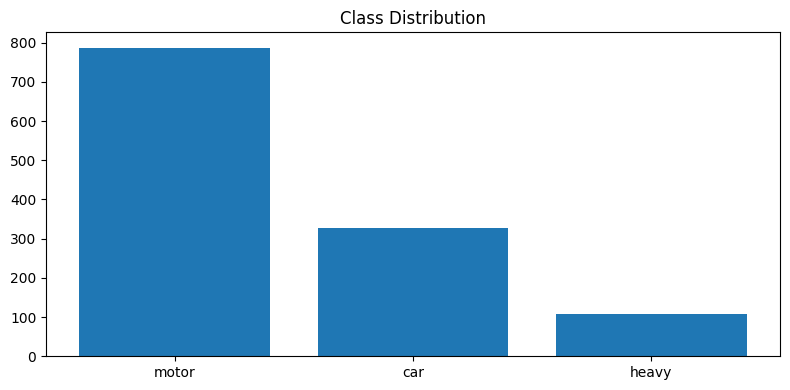

In [ ]:
import os
import json
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

config_path = 'project/config/default.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

with open(config['dataset']['split_manifest'], 'r') as f:
    split_manifest = json.load(f)

class_names = config['dataset']['names']
class_counts = defaultdict(int)
split_counts = {}
empty_labels = 0
rows = []
for split_name in ['train_data', 'val_data', 'test_data']:
    split_counts[split_name] = len(split_manifest.get(split_name, []))
    for _, label_path in split_manifest.get(split_name, []):
        with open(label_path, 'r') as f:
            label_lines = [line.strip() for line in f if line.strip()]
        if not label_lines:
            empty_labels += 1
        for line in label_lines:
            parts = line.split()
            if len(parts) != 5:
                continue
            class_id = int(float(parts[0]))
            cx, cy, w, h = map(float, parts[1:])
            class_counts[class_id] += 1
            rows.append({'class_id': class_id, 'w': w, 'h': h, 'area': w * h})

print(f"Split counts: {split_counts}")
print(f"Empty label files: {empty_labels}")
print('Class distribution:')
for class_id in sorted(class_counts):
    name = class_names[class_id] if class_id < len(class_names) else str(class_id)
    print(f"  {name}: {class_counts[class_id]}")

df = pd.DataFrame(rows)
if not df.empty:
    labels = [class_names[c] if c < len(class_names) else str(c) for c in sorted(class_counts)]
    values = [class_counts[c] for c in sorted(class_counts)]
    plt.figure(figsize=(8, 4))
    plt.bar(labels, values)
    plt.title('Class Distribution')
    plt.tight_layout()
    plt.show()

## 8. Generate YOLO `data.yaml`

Skipped when the Drive model exists.

In [ ]:
import os
import yaml

config_path = 'project/config/default.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

if config.get('SKIP_TRAINING', False):
    print('Skipping data.yaml generation because SKIP_TRAINING=True.')
else:
    data_yaml_path = os.path.join(config['paths']['config'], 'yolov8_data.yaml')
    data_yaml = {
        'train': os.path.abspath(config['dataset']['train_path']),
        'val': os.path.abspath(config['dataset']['val_path']),
        'test': os.path.abspath(config['dataset']['test_path']),
        'nc': len(config['dataset']['names']),
        'names': config['dataset']['names'],
    }
    with open(data_yaml_path, 'w') as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False)
    config['training']['data_yaml'] = data_yaml_path
    with open(config_path, 'w') as f:
        yaml.safe_dump(config, f, sort_keys=False)
    print(f'YOLO data.yaml generated at: {data_yaml_path}')

Skipping data.yaml generation because SKIP_TRAINING=True.


## 9. Train YOLOv8n Model

Skipped when the Drive model exists. Artifact paths are resolved from `results.save_dir`.

In [ ]:
import os
import yaml
import shutil
from pathlib import Path

config_path = 'project/config/default.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

if config.get('SKIP_TRAINING', False):
    print('Skipping training because SKIP_TRAINING=True.')
else:
    from ultralytics import YOLO

    data_yaml = config['training'].get('data_yaml')
    if not data_yaml or not os.path.exists(data_yaml):
        raise FileNotFoundError('YOLO data.yaml is missing. Run Section 8 first.')

    model = YOLO(config['training']['model'])
    train_args = {
        'data': data_yaml,
        'imgsz': config['training']['imgsz'],
        'epochs': config['training']['epochs'],
        'batch': config['training']['batch'],
        'patience': config['training']['patience'],
        'project': config['training']['project'],
        'name': config['training']['name'],
        'device': config['inference']['device'],
    }
    results = model.train(**train_args)
    save_dir = Path(results.save_dir)
    outputs = Path(config['paths']['outputs'])
    outputs.mkdir(parents=True, exist_ok=True)

    for src in [save_dir / 'weights' / 'best.pt', save_dir / 'weights' / 'last.pt', save_dir / 'results.csv', save_dir / 'confusion_matrix.png', save_dir / 'PR_curve.png', save_dir / 'F1_curve.png', save_dir / 'labels.jpg']:
        if src.exists():
            shutil.copy2(src, outputs / src.name)
            print(f'Copied {src} -> {outputs / src.name}')
        else:
            print(f'Warning: training artifact not found: {src}')

    best_path = outputs / 'best.pt'
    if best_path.exists():
        config['inference']['model_path'] = str(best_path)
        with open(config_path, 'w') as f:
            yaml.safe_dump(config, f, sort_keys=False)
        print(f'Inference model path set to: {best_path}')

Skipping training because SKIP_TRAINING=True.


## 10. Implement Image Inference Modules (`project/src`)

In [ ]:
import os
import textwrap

src_path = 'project/src'
os.makedirs(src_path, exist_ok=True)

modules = {
    'inference_engine.py': r'''
from ultralytics import YOLO

class InferenceEngine:
    def __init__(self, config):
        self.config = config
        self.model_path = config['inference']['model_path']
        self.conf_threshold = config['inference']['conf_threshold']
        self.iou_threshold = config['inference']['iou_threshold']
        self.device = config['inference']['device']
        self.class_names = config['dataset'].get('names', ['motor', 'car', 'heavy'])
        print(f"Loading YOLO model from: {self.model_path}")
        self.model = YOLO(self.model_path)

    def run_inference(self, image):
        results = self.model(image, conf=self.conf_threshold, iou=self.iou_threshold, device=self.device, verbose=False)[0]
        detections = []
        if results.boxes is not None:
            for *xyxy, conf, cls in results.boxes.data.tolist():
                class_id = int(cls)
                if class_id < len(self.class_names):
                    detections.append([int(xyxy[0]), int(xyxy[1]), int(xyxy[2]), int(xyxy[3]), float(conf), class_id, self.class_names[class_id]])
        return detections
''',
    'roi_engine.py': r'''
import cv2
import numpy as np

class ROIEngine:
    def __init__(self, config):
        self.config = config
        self.roi_polygons = config['roi_counting']['roi_polygons']

    def assign_detection_to_roi(self, detection, image_width, image_height):
        x1, y1, x2, y2 = detection[:4]
        center = ((x1 + x2) / 2, (y1 + y2) / 2)
        # First-match assignment is intentional if manually edited ROIs overlap later.
        for direction, polygon_points in self.roi_polygons.items():
            if polygon_points and len(polygon_points) >= 3:
                polygon_np = np.array(polygon_points, np.int32)
                if cv2.pointPolygonTest(polygon_np, center, False) >= 0:
                    return direction
        return None

    def count_vehicles_in_rois(self, detections, image_width, image_height):
        counts = {direction: 0 for direction in self.roi_polygons.keys()}
        assigned = {direction: [] for direction in self.roi_polygons.keys()}
        unassigned = []
        for detection in detections:
            direction = self.assign_detection_to_roi(detection, image_width, image_height)
            if direction:
                counts[direction] += 1
                assigned[direction].append(detection)
            else:
                unassigned.append(detection)
        return counts, assigned, unassigned
''',
    'logger.py': r'''
import os
import json

class Logger:
    def __init__(self, config):
        self.config = config
        self.outputs_path = config['paths']['outputs']
        os.makedirs(self.outputs_path, exist_ok=True)

    def save_detection_json(self, result):
        filename = self.config['output_files'].get('detection_result_json', 'detection_result.json')
        path = os.path.join(self.outputs_path, filename)
        with open(path, 'w') as f:
            json.dump(result, f, indent=2)
        print(f"Detection JSON saved to {path}")
        return path
''',
    'visualization.py': r'''
import cv2
import numpy as np

class VisualizationEngine:
    def __init__(self, config):
        self.config = config
        self.colors = {
            'motor': (0, 255, 0),
            'car': (255, 0, 0),
            'heavy': (0, 0, 255),
            'North': (255, 255, 0),
            'East': (0, 255, 255),
            'South': (255, 0, 255),
            'West': (128, 0, 128),
            'Unassigned': (200, 200, 200),
        }

    def draw_detections(self, image, detections, roi_counts):
        annotated = image.copy()
        for direction, points in self.config['roi_counting']['roi_polygons'].items():
            if points and len(points) >= 3:
                polygon_np = np.array(points, np.int32)
                color = self.colors.get(direction, (255, 255, 255))
                cv2.polylines(annotated, [polygon_np], True, color, 2)
                cv2.putText(annotated, direction, tuple(polygon_np[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
        for detection in detections:
            x1, y1, x2, y2 = detection['bbox']
            class_name = detection['class_name']
            confidence = detection['confidence']
            direction = detection.get('roi_direction') or 'Unassigned'
            color = self.colors.get(class_name, (0, 255, 0))
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            cv2.putText(annotated, f"{class_name} {confidence:.2f} {direction}", (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        y = 30
        for direction in ['North', 'East', 'South', 'West']:
            cv2.putText(annotated, f"{direction}: {roi_counts.get(direction, 0)}", (10, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            y += 25
        return annotated
'''
}

with open(os.path.join(src_path, '__init__.py'), 'w') as f:
    f.write('')
for filename, content in modules.items():
    module_path = os.path.join(src_path, filename)
    with open(module_path, 'w') as f:
        f.write(textwrap.dedent(content).lstrip())
    print(f'Created {module_path}')

Created project/src/inference_engine.py
Created project/src/roi_engine.py
Created project/src/logger.py
Created project/src/visualization.py


## 11. Select Random Test Image & Generate Automatic ROIs

Selects a random BMD-45 processed image without repeating until the image history is exhausted. ROIs are generated from image dimensions and checked with Shapely.

In [ ]:
import os
import json
import random
import yaml
from PIL import Image
from shapely.geometry import Polygon

config_path = 'project/config/default.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

with open(config['dataset'].get('processed_manifest', 'project/data/processed/processed_manifest.json'), 'r') as f:
    manifest = json.load(f)

candidate_images = [path for path in manifest.get('processed_image_paths', []) if os.path.exists(path)]
if not candidate_images:
    raise ValueError('No processed images available for random selection.')

history_path = config['test']['session_history']
used_images = []
if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        used_images = json.load(f)

available = [path for path in candidate_images if path not in used_images]
if not available:
    print('All images used once. Resetting image history.')
    used_images = []
    available = candidate_images

selected_image_path = random.choice(available)
used_images.append(selected_image_path)
os.makedirs(os.path.dirname(history_path), exist_ok=True)
with open(history_path, 'w') as f:
    json.dump(used_images, f, indent=2)

with Image.open(selected_image_path) as img:
    width, height = img.width, img.height


def scale(points):
    return [[int(width * x), int(height * y)] for x, y in points]


def overlaps(rois):
    names = list(rois)
    polygons = {name: Polygon(rois[name]) for name in names}
    result = []
    for i, first in enumerate(names):
        for second in names[i + 1:]:
            area = polygons[first].intersection(polygons[second]).area
            if area > 0:
                result.append((first, second, area))
    return result


def shrink(points, factor=0.90):
    polygon = Polygon(points)
    c = polygon.centroid
    return [[int(c.x + (x - c.x) * factor), int(c.y + (y - c.y) * factor)] for x, y in points]

roi_polygons = {
    'North': scale([(0.35, 0.02), (0.65, 0.02), (0.58, 0.42), (0.42, 0.42)]),
    'East': scale([(0.62, 0.35), (0.98, 0.28), (0.98, 0.72), (0.62, 0.58)]),
    'South': scale([(0.42, 0.62), (0.58, 0.62), (0.65, 0.98), (0.35, 0.98)]),
    'West': scale([(0.02, 0.28), (0.38, 0.35), (0.38, 0.58), (0.02, 0.72)]),
}

found_overlaps = overlaps(roi_polygons)
if found_overlaps:
    print('ROI overlaps detected. Shrinking polygons once.')
    roi_polygons = {name: shrink(points) for name, points in roi_polygons.items()}
    found_overlaps = overlaps(roi_polygons)

if found_overlaps:
    for first, second, area in found_overlaps:
        print(f'Warning: {first} and {second} overlap by {area:.2f} pixels.')
else:
    print('ROI overlap check passed.')

config['roi_counting']['roi_polygons'] = roi_polygons
config['test']['selected_image_path'] = selected_image_path
config['test']['selected_image_dimensions'] = [width, height]
with open(config_path, 'w') as f:
    yaml.safe_dump(config, f, sort_keys=False)

print(f'Selected image: {selected_image_path}')
print(f'Image dimensions: {width}x{height}')

ROI overlap check passed.
Selected image: project/data/processed/images/bmd45_train/train_50604_990647.png
Image dimensions: 1920x1080


## 12. Run Detection & Output JSON

Outputs a REST API-friendly JSON file with bounding box coordinates, confidence, class ID, class name, and optional ROI direction.

In [ ]:
import os
import sys
import json
import cv2
import yaml

sys.path.insert(0, os.getcwd())
from project.src.inference_engine import InferenceEngine
from project.src.roi_engine import ROIEngine
from project.src.logger import Logger

config_path = 'project/config/default.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

image_path = config['test'].get('selected_image_path')
model_path = config['inference'].get('model_path')
if not image_path or not os.path.exists(image_path):
    raise FileNotFoundError('Selected image missing. Run Section 11 first.')
if not model_path or not os.path.exists(model_path):
    raise FileNotFoundError(f'Model path missing or invalid: {model_path}')

image = cv2.imread(image_path)
if image is None:
    raise ValueError(f'Could not read image: {image_path}')
height, width = image.shape[:2]

inference_engine = InferenceEngine(config)
roi_engine = ROIEngine(config)
logger = Logger(config)
raw_detections = inference_engine.run_inference(image)
roi_counts, assigned, unassigned = roi_engine.count_vehicles_in_rois(raw_detections, width, height)

detections = []
for detection in raw_detections:
    detections.append({
        'bbox': [int(detection[0]), int(detection[1]), int(detection[2]), int(detection[3])],
        'confidence': float(detection[4]),
        'class_id': int(detection[5]),
        'class_name': detection[6],
        'roi_direction': roi_engine.assign_detection_to_roi(detection, width, height),
    })

result = {
    'image_path': image_path,
    'image_dimensions': [width, height],
    'detections': detections,
    'roi_counts': roi_counts,
    'unassigned_count': len(unassigned),
}

result_path = logger.save_detection_json(result)
print(json.dumps(result, indent=2))
print(f'Total detections: {len(detections)}')
print(f'Detection result path: {result_path}')

Loading YOLO model from: /content/drive/MyDrive/traffic_light_ai_project/outputs/best.pt
Detection JSON saved to project/outputs/detection_result.json
{
  "image_path": "project/data/processed/images/bmd45_train/train_50604_990647.png",
  "image_dimensions": [
    1920,
    1080
  ],
  "detections": [
    {
      "bbox": [
        1416,
        526,
        1512,
        625
      ],
      "confidence": 0.8339007496833801,
      "class_id": 1,
      "class_name": "car",
      "roi_direction": "East"
    },
    {
      "bbox": [
        0,
        451,
        25,
        528
      ],
      "confidence": 0.5534070134162903,
      "class_id": 1,
      "class_name": "car",
      "roi_direction": null
    },
    {
      "bbox": [
        942,
        398,
        970,
        442
      ],
      "confidence": 0.25444653630256653,
      "class_id": 0,
      "class_name": "motor",
      "roi_direction": "North"
    }
  ],
  "roi_counts": {
    "North": 1,
    "East": 1,
    "South": 0,
    "W

## 13. Visualize Annotated Result

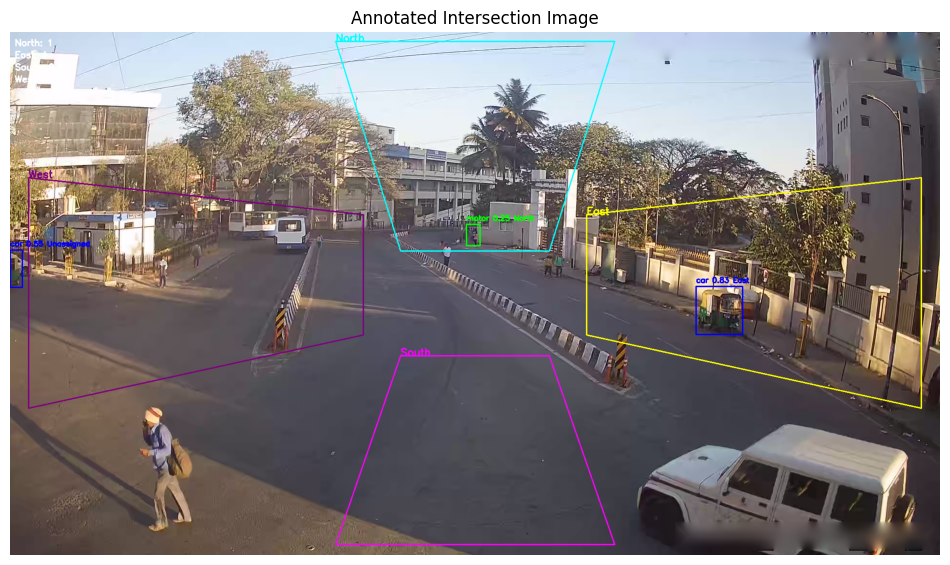

Annotated image saved to: project/outputs/annotated_intersection.jpg


In [ ]:
import os
import sys
import json
import cv2
import yaml
import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())
from project.src.visualization import VisualizationEngine

config_path = 'project/config/default.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

result_path = os.path.join(config['paths']['outputs'], config['output_files']['detection_result_json'])
if not os.path.exists(result_path):
    raise FileNotFoundError('Detection JSON not found. Run Section 12 first.')

with open(result_path, 'r') as f:
    result = json.load(f)

image = cv2.imread(result['image_path'])
if image is None:
    raise ValueError(f"Could not read image: {result['image_path']}")

visualizer = VisualizationEngine(config)
annotated = visualizer.draw_detections(image, result['detections'], result['roi_counts'])
annotated_path = os.path.join(config['paths']['outputs'], config['output_files']['annotated_image'])
cv2.imwrite(annotated_path, annotated)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Annotated Intersection Image')
plt.show()

print(f'Annotated image saved to: {annotated_path}')